#**Section A: Web Scraper & Text Chunking**

This section focusing on acquiring raw data from the web and text.

 - We use trafilatura as our primary extraction tool to automatically parse URLs and isolate the main article body while discarding irrelevant boilerplate code.

 - Because some websites use complex rendering that obscures metadata, we implemented a fallback mechanism using BeautifulSoup to reliably capture the article's title tag if the primary extractor fails.

 - Once the raw content is secured, a custom preprocessing function normalizes the text spacing and chunks it into uniform 200-word segments, ensuring the data respects the strict token limits of downstream machine learning models.

 - Finally, this entire robust architecture is wrapped in a dynamic, interactive command-line interface that easily processes both live URLs and direct text inputs for our AI.

###**Step 1: Install trafilatura (Extraction tool)**

In [ ]:
# Install trafilatura
!pip install trafilatura

!pip install contractions nltk transformers torch
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

###**Step 2: Data Normalization and Chunking**

- Raw text scraped from the internet is often messy, containing irregular spacing and hidden line breaks.

- Furthermore, NLP models have strict "token limits" (a maximum amount of text they can process at one time).

- This helper function normalizes the text string and divides it into uniform arrays called "chunks".

In [ ]:
def _clean_and_chunk_text(text, chunk_size):
    """
    Normalizes raw text spacing and splits it into manageable chunks.
    """
    clean_text = " ".join(text.split())
    words = clean_text.split()
    chunks = []
    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i + chunk_size])
        chunks.append(chunk)
    return clean_text, chunks

### **Step 3: The Data Acquisition Engine (With Tag-Team Backup)**

- Core web scraping function.

- It uses heuristic algorithms to identify and extract the main body of a news article while ignoring boilerplate code (like menus and ads).

- Because metadata architecture varies across websites, we employ a "fallback mechanism": if the primary extractor fails to locate the `<title>` tag, a secondary DOM parser (`BeautifulSoup`) is automatically triggered to retrieve it.

In [ ]:
import trafilatura
import requests
from bs4 import BeautifulSoup

def get_raw_article_trafilatura(url, chunk_size=200):
    """
    Scrapes a news article from a given URL using Trafilatura.
    Uses BeautifulSoup as a fallback if the title is missing.
    """
    print(f"Fetching URL: {url}...")

    downloaded = trafilatura.fetch_url(url)

    if downloaded is None:
        print("❌ Oops! Couldn't access the website.")
        return {"title": "Error", "full_cleaned_text": "", "text_chunks": [], "top_image": "N/A", "original_text_length": 0, "num_chunks": 0}

    extracted_data = trafilatura.bare_extraction(downloaded)

    if extracted_data is None:
        print("⚠️ Downloaded the page, but couldn't extract anything!")
        return {"title": "Error", "full_cleaned_text": "", "text_chunks": [], "top_image": "N/A", "original_text_length": 0, "num_chunks": 0}

    if hasattr(extracted_data, 'text'):
        raw_text = extracted_data.text
        article_title = extracted_data.title
    elif isinstance(extracted_data, dict):
        raw_text = extracted_data.get('text')
        article_title = extracted_data.get('title')
    else:
        raw_text = None
        article_title = None

    # Final check for text
    if not raw_text:
        print("⚠️ Downloaded the page, but couldn't find any text!")
        return {"title": "Error", "full_cleaned_text": "", "text_chunks": [], "top_image": "N/A", "original_text_length": 0, "num_chunks": 0}

    # If Trafilatura couldn't find the title, send in BeautifulSoup!
    if not article_title:
        try:
            print("⚠️ Title missing! Sending in BeautifulSoup backup...")
            # Quickly fetch just the HTML shell
            response = requests.get(url, timeout=5)
            soup = BeautifulSoup(response.content, 'html.parser')
            # Look directly for the <title> tag
            if soup.title and soup.title.string:
                article_title = soup.title.string.strip()
            else:
                article_title = "No Title Found"
        except Exception as e:
            # If the backup also fails, we just accept defeat gracefully
            article_title = "No Title Found"

    # Use our helper function to clean and chunk!
    clean_text, chunks = _clean_and_chunk_text(raw_text, chunk_size)

    return {
        "title": article_title,
        "full_cleaned_text": clean_text,
        "text_chunks": chunks,
        "top_image": "N/A",
        "original_text_length": len(clean_text.split()),
        "num_chunks": len(chunks)
    }

### **Step 4: The Manual Override**

This function bypasses the web scraper entirely, allowing users to input raw string data directly into the cleaning and chunking pipeline.

In [ ]:
def process_direct_text(text_input, chunk_size=200):
    clean_text, chunks = _clean_and_chunk_text(text_input, chunk_size)
    return {
        "title": "User Provided Text",
        "full_cleaned_text": clean_text,
        "text_chunks": chunks,
        "top_image": "N/A",
        "original_text_length": len(clean_text.split()),
        "num_chunks": len(chunks)
    }

### **Step 5: Refined Chunking Strategy - Sentence-based with Token Limits and Overlap**


As described in our proposal, to effectively handle long articles for transformer models like BART (which have token limits), we need a more sophisticated chunking mechanism. The goal is to:

1.  **Cut at sentence boundaries**: Avoid splitting sentences mid-way, preserving semantic meaning.
2.  **Respect token limits**: Ensure each chunk does not exceed the model's maximum token input (e.g., 1024 for BART).
3.  **Include overlap**: Provide context by including a few sentences from the end of the previous chunk at the beginning of the next.

Below is the `chunk_by_sentences_and_tokens` function that implements this sliding window strategy. It replaces the simpler word-based chunking in our processing pipeline.

In [ ]:
def chunk_by_sentences_and_tokens(sentences: list[str], tokenizer, max_tokens: int = 1024, overlap_sentences: int = 3) -> list[str]:
    """
    Chunks a list of sentences into larger segments, respecting a maximum token limit
    and providing overlap between chunks.
    """
    if not sentences:
        return []

    chunks = []
    current_chunk_sentences = []
    current_token_count = 0

    for i, sentence in enumerate(sentences):
        # Encode sentence without special tokens to get its true token length
        sentence_tokens = tokenizer.encode(sentence, add_special_tokens=False)
        sentence_token_count = len(sentence_tokens)

        # Check if adding this sentence exceeds the max_tokens. If it does,
        # and we already have content in the current chunk, finalize it and start a new one.
        if current_token_count + sentence_token_count > max_tokens and current_chunk_sentences:
            chunks.append(" ".join(current_chunk_sentences))

            # For the next chunk, include an overlap from the end of the previous chunk.
            # This maintains context across chunk boundaries.
            overlap_start_index = max(0, len(current_chunk_sentences) - overlap_sentences)
            current_chunk_sentences = list(current_chunk_sentences[overlap_start_index:])

            # Recalculate token count for the new chunk (including overlap)
            current_token_count = len(tokenizer.encode(" ".join(current_chunk_sentences), add_special_tokens=False))

        # Add the current sentence to the working chunk
        current_chunk_sentences.append(sentence)
        current_token_count += sentence_token_count

    # Add any remaining sentences as the final chunk
    if current_chunk_sentences:
        chunks.append(" ".join(current_chunk_sentences))

    return chunks

### **Step 6: Pipeline Integration and User Interface (UI)**

Captures user input, dynamically routes the request to either the web scraper or the manual text processor, and formats the returned dictionary into a readable report for validation.

This section explains the key preprocessing tools, techniques and function used before summarisation:

* re – regular expressions, used to remove any remaining non‑ASCII characters.

* contractions – a library that expands English contractions (e.g., "it's" → "it is", "don't" → "do not"). This makes the text more standard for the summariser.

* nltk – Natural Language Toolkit; we use its sentence tokenizer to split text into individual sentences.

* sent_tokenize – the specific NLTK function that finds sentence boundaries (., ?, !, etc.) even with abbreviations like “Dr.” or “U.S.”.

* AutoTokenizer – from HuggingFace Transformers. It loads the tokenizer that matches the BART model, which converts text into numeric IDs that the model understands.

* **Load the BART Tokenizer**

  We use BART (or T5) for abstractive summarisation. The tokenizer tells exactly how many “tokens” (sub‑word pieces) your text occupies – crucial because BART has a maximum of 1024 tokens per input. If the tokenizer can’t be downloaded (no internet or missing transformers), the code sets bart_tokenizer = None and later falls back to a rough word‑count estimate.


* **Sentence segmentation**

  Uses NLTK’s unsupervised sentence boundary detector (the punkt model). Splits text like "Mr. Smith arrived. He sat down." into ["Mr. Smith arrived.", "He sat down."] – correctly handling the “Mr.” abbreviation. When you want to chunk long articles (because of the 1024 token limit), you want to cut at sentence boundaries, not in the middle of a sentence. This preserves meaning.The original chunking splits every 200 words arbitrarily while sentences list is smarter.


* **Tokenization**

  The bart_tokenizer.encode() converts the string into a list of token IDs (including BART’s special tokens like <s> and </s>). The length of that list is the true token count. If the token count exceeds 1024, the model will automatically truncate the input, potentially losing important information at the end. The function returns a warning so the user knows. If no tokenizer, splits by whitespace (words). This is less accurate but better than nothing.


* **Noise filtering**

  If the article has fewer than 50 words, it’s probably not a real news story – e.g., a caption, a tweet, or an error page. The summariser would produce a useless summary. Any article that contains these common “boilerplate” phrases (cookie policies, subscription prompts, copyright notices) is likely not genuine news content – or it’s an ad‑ridden page.

* Case‑insensitive: Everything is lowercased before checking.

The function returns suitable: False with a reason. Then, the output report will warn the user that this article is not suitable for summarisation.


In [ ]:
import re
import contractions
import nltk
from nltk.tokenize import sent_tokenize
from transformers import AutoTokenizer
import textwrap


input_choice = input("Enter 'url' to provide an article URL or 'text' to provide raw article text: ").strip().lower()
processed_data = {}
chunk_size_demo = 200

print(f"\nSelected Input Type: {input_choice}")

if input_choice == 'url':
    url_input = input("Please paste a news article URL: ").strip()
    if url_input:
        print(f"\nProcessing article from URL using Trafilatura: {url_input}")
        processed_data = get_raw_article_trafilatura(url_input, chunk_size=chunk_size_demo)
    else:
        print("No URL provided.")
        processed_data = {"title": "Error", "full_cleaned_text": "No URL provided.", "text_chunks": [], "top_image": "N/A", "original_text_length": 0, "num_chunks": 0}

elif input_choice == 'text':
    raw_text_input = input("Please paste the raw article text: ").strip()
    if raw_text_input:
        print("\nProcessing user-provided text...")
        processed_data = process_direct_text(raw_text_input, chunk_size=chunk_size_demo)
    else:
        print("No raw text provided.")
        processed_data = {"title": "Error", "full_cleaned_text": "No text provided.", "text_chunks": [], "top_image": "N/A", "original_text_length": 0, "num_chunks": 0}
else:
    print("Invalid input type selected.")
    processed_data = {"title": "Error", "full_cleaned_text": "Invalid input type selection.", "text_chunks": [], "top_image": "N/A", "original_text_length": 0, "num_chunks": 0}


# Load BART tokenizer once (cached for efficiency)
try:
    bart_tokenizer = AutoTokenizer.from_pretrained("facebook/bart-base")
except Exception as e:
    print("⚠️ Could not load BART tokenizer. Token count will be estimated with whitespace.")
    bart_tokenizer = None

# Normalization
def normalize_text(text: str) -> str:
    """
    1. Replace non-ASCII punctuation with standard ASCII equivalents.
    2. Expand contractions (e.g., "it's" -> "it is").
    """
    # Replace common non‑ASCII quotes, dashes, ellipsis, etc.
    replacements = {
        '’': "'", '‘': "'", '“': '"', '”': '"',
        '—': '-', '–': '-', '…': '...', '•': '*'
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)

    # Expand contractions (e.g., don't -> do not)
    text = contractions.fix(text)

    # Optionally remove any remaining non‑ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    return text

# Sentence segmentation
def segment_sentences(text: str) -> list:
    """
    Split normalized text into a list of sentences using NLTK.
    """
    sentences = sent_tokenize(text)
    return sentences

# Tokenization Analysis
def analyze_tokenization(text: str, model_max_length: int = 1024) -> dict:
    """
    Count tokens with BART tokenizer and check if text exceeds model limit.
    Returns dict with token_count, exceeds_limit, and warning message.
    """
    if bart_tokenizer is None:
        # Fallback: rough estimate with whitespace
        token_count = len(text.split())
        warning = "⚠️ Using fallback token count (whitespace split). Install transformers for accurate counts."
    else:
        tokens = bart_tokenizer.encode(text, add_special_tokens=True)
        token_count = len(tokens)
        warning = None

    exceeds_limit = token_count > model_max_length
    if exceeds_limit and warning is None:
        warning = f"⚠️ Text has {token_count} tokens, exceeding model limit of {model_max_length}. Will be truncated."

    return {
        "token_count": token_count,
        "exceeds_limit": exceeds_limit,
        "warning": warning
    }

# Noise Filtering
JUNK_PHRASES = [
    "cookie policy", "privacy policy", "terms of service", "sign up",
    "subscribe now", "advertisement", "all rights reserved",
    "this site uses cookies", "download our app", "newsletter"
]

def quality_filter(text: str, min_words: int = 50) -> dict:
    """
    Flag text as unsuitable if:
    - Word count < min_words
    - Contains any junk phrase (case‑insensitive)
    Returns dict with suitable (bool) and reason (str or None).
    """
    word_count = len(text.split())

    if word_count < min_words:
        return {
            "suitable": False,
            "reason": f"Too short: {word_count} words (minimum {min_words})"
        }

    lower_text = text.lower()
    for junk in JUNK_PHRASES:
        if junk in lower_text:
            return {
                "suitable": False,
                "reason": f"Contains junk phrase: '{junk}'"
            }

    return {"suitable": True, "reason": None}

# Integrate all task into pipeline
def process_article_with_refinement(article_data: dict, max_chunk_tokens: int = 1024, overlap_sents: int = 3) -> dict:
    """
    Takes the output of get_raw_article_trafilatura or process_direct_text
    and adds NLP specialist refinements, including advanced chunking.
    """
    raw_cleaned_text = article_data.get("full_cleaned_text", "")
    if not raw_cleaned_text:
        article_data["refinement"] = {"error": "No text to refine"}
        return article_data

    # Task 1: Normalization
    normalized_text = normalize_text(raw_cleaned_text)

    # Task 2: Sentence segmentation
    sentences = segment_sentences(normalized_text)

    # Task 3: Tokenization analysis
    token_info = analyze_tokenization(normalized_text)

    # Task 4: Noise filtering
    quality = quality_filter(normalized_text)

    # Task 5: Advanced Chunking using sentences and token limits
    # This replaces the old 'text_chunks' directly
    if bart_tokenizer: # Only apply advanced chunking if BART tokenizer is available
        refined_chunks = chunk_by_sentences_and_tokens(
            sentences=sentences,
            tokenizer=bart_tokenizer,
            max_tokens=max_chunk_tokens,
            overlap_sentences=overlap_sents
        )
    else:
        # Fallback to simple word-based chunking if tokenizer is not available
        # Note: This is a less ideal fallback and might still exceed token limits
        clean_text_for_fallback, simple_chunks = _clean_and_chunk_text(raw_cleaned_text, chunk_size=200) # Re-using old chunk_size
        refined_chunks = simple_chunks

    # Add all results to the article data
    article_data["refinement"] = {
        "normalized_text": normalized_text,
        "sentences": sentences,
        "num_sentences": len(sentences),
        "token_analysis": token_info,
        "quality_filter": quality
    }
    article_data["refined_chunks"] = refined_chunks # Add the new chunks
    article_data["num_chunks"] = len(refined_chunks) # Update num_chunks with refined count

    # Update the cleaned text to normalized version and overwrite the old one
    article_data["full_cleaned_text"] = normalized_text

    return article_data



if processed_data and processed_data.get("full_cleaned_text") not in [None, "", "No URL provided.", "No text provided."]:
    # Apply all NLP refinements
    # Pass max_chunk_tokens and overlap_sents to the function
    processed_data = process_article_with_refinement(processed_data, max_chunk_tokens=1024, overlap_sents=3)

# Output display
print("\n" + "="*30)
print("PROCESSED DATA REPORT")
print("="*30)
print(f"Title: {processed_data['title']}")
print(f"Top Image: {processed_data['top_image']}")
print(f"Original Cleaned Text Length: {processed_data['original_text_length']} words")

# Noise filter result
ref = processed_data.get("refinement", {})
if ref.get("quality_filter"):
    qf = ref["quality_filter"]
    if qf["suitable"]:
        print("✅ Quality Filter: SUITABLE for summarization")
    else:
        print(f"❌ Quality Filter: NOT SUITABLE – {qf['reason']}")
else:
    print("⚠️ Quality Filter: Not applied (no text)")

# Token analysis
if ref.get("token_analysis"):
    ta = ref["token_analysis"]
    print(f"Token Count (BART): {ta['token_count']}")
    if ta["exceeds_limit"]:
        print(ta["warning"])
    else:
        print("✅ Token count within model limit (1024)")

print(f"Number of Chunks (refined method): {processed_data['num_chunks']}") # Updated output for new chunks
print(f"Number of Sentences (NLTK): {ref.get('num_sentences', 0)}")

if processed_data['full_cleaned_text']:
    print("\n[Preview of Normalized Text]")
    print(textwrap.fill(processed_data['full_cleaned_text'][:300] + "\n", width=100))
else:
    print("\nNo normalized text available.")

if ref.get("sentences"):
    print("\n[First 3 Sentences]")
    for i, sent in enumerate(ref["sentences"][:3]):
        preview = sent[:150] + "..." if len(sent) > 150 else sent
        print(f"{i+1}. {textwrap.fill(preview, width=100)}")

# Displaying refined chunks
if processed_data.get("refined_chunks"):
    print("\n[Refined Chunks Preview (first 2)]")
    for i, chunk in enumerate(processed_data["refined_chunks"][:2]):
        print(f"Chunk {i+1} (Length: {len(bart_tokenizer.encode(chunk, add_special_tokens=False))} tokens)\n{textwrap.fill(chunk[:200] + "...", width=100)}")
else:
    print("\nNo refined chunks found.")


# EVALUATION PART

import re

def evaluate_refinement_quality(processed_data):
    """
    Takes the output dictionary from process_article_with_refinement()
    and returns a detailed quality report.
    """
    print("\n" + "="*50)
    print("📊 NLP REFINEMENT QUALITY EVALUATION")
    print("="*50)

    # Check if refinement was applied
    ref = processed_data.get("refinement", {})
    if not ref:
        print("❌ ERROR: No refinement data found. Did you run process_article_with_refinement()?")
        return

    text = processed_data.get("full_cleaned_text", "")
    if not text:
        print("❌ ERROR: No cleaned text available.")
        return

    # Non-ASCII character check
    non_ascii = re.findall(r'[^\x00-\x7F]', text)
    if non_ascii:
        print(f"❌ FAIL: Found {len(non_ascii)} non-ASCII characters: {set(non_ascii)}")
        print("   → Normalization incomplete. Check normalize_text() replacements.")
    else:
        print("✅ PASS: No non-ASCII characters (pure ASCII).")

    # Contraction expansion check
    common_contractions = ["'s", "n't", "'ll", "'re", "'ve", "'m", "'d"]
    found = [c for c in common_contractions if c in text]
    if found:
        print(f"⚠️ WARNING: Unexpanded contractions found: {found}")
        print("   → contractions.fix() may have missed some. Check input text for unusual apostrophes.")
    else:
        print("✅ PASS: No common contractions – text is well expanded.")

    # Sentene segmentation plausibility
    sentences = ref.get("sentences", [])
    if not sentences:
        print("❌ FAIL: No sentences detected. Segmentation failed.")
    else:

        endings = text.count('.') + text.count('?') + text.count('!')
        if endings == 0:
            print("⚠️ WARNING: No sentence ending punctuation found.")
        elif len(sentences) < endings * 0.3:
            print(f"⚠️ WARNING: {len(sentences)} sentences but {endings} punctuation marks.")
            print("   → Possible segmentation error (too few sentences).")
        elif len(sentences) > endings * 1.5:
            print(f"⚠️ WARNING: {len(sentences)} sentences but only {endings} endings.")
            print("   → Possible over‑segmentation (splitting inside sentences).")
        else:
            print(f"✅ PASS: {len(sentences)} sentences, {endings} ending marks – plausible ratio.")

        # Show first 2 sentences for manual inspection
        print("\n   First 2 sentences (manual check):")
        for i, s in enumerate(sentences[:2]):
            preview = s[:120] + "..." if len(s) > 120 else s
            print(f"   {i+1}. {textwrap.fill(preview, width=100)}")

    # Token count sanity
    token_info = ref.get("token_analysis", {})
    if not token_info:
        print("❌ FAIL: No token analysis data.")
    else:
        token_count = token_info.get("token_count", 0)
        word_count = len(text.split())
        if token_count == 0:
            print("❌ FAIL: Token count is zero.")
        else:
            ratio = token_count / word_count
            if 1.1 <= ratio <= 1.6:
                print(f"✅ PASS: Token/word ratio = {ratio:.2f} (normal for BART).")
            else:
                print(f"⚠️ WARNING: Token/word ratio = {ratio:.2f} (typical is 1.2–1.5).")
                if ratio < 1.0:
                    print("   → Possibly tokenizer fallback used (whitespace split). Install transformers.")
                else:
                    print("   → Text may have many rare words or special tokens.")

        if token_info.get("exceeds_limit"):
            print(f"⚠️ WARNING: Token count ({token_count}) exceeds model limit (1024).")
            print("   → Text will be truncated; consider chunking more finely.")
        else:
            print(f"✅ PASS: Token count ({token_count}) within 1024 limit.")

    qf = ref.get("quality_filter", {})
    if qf.get("suitable"):
        print("✅ PASS: Quality filter says article is SUITABLE for summarization.")
    else:
        reason = qf.get("reason", "unknown")
        print(f"❌ FAIL: Quality filter rejected article – {reason}")

    # Final inspection
    fail_flags = 0
    if non_ascii: fail_flags += 1
    if found: fail_flags += 0.5
    if not sentences: fail_flags += 1
    if token_count == 0: fail_flags += 1
    if not qf.get("suitable"): fail_flags += 1

    if fail_flags == 0:
        print("🎉 OVERALL VERDICT: GOOD – Refinement is accurate.")
    elif fail_flags <= 2:
        print("📌 OVERALL VERDICT: MODERATE – Minor issues, but usable.")
    else:
        print("⚠️ OVERALL VERDICT: POOR – Refinement needs improvement.")

    print("="*50 + "\n")

evaluate_refinement_quality(processed_data)


Enter 'url' to provide an article URL or 'text' to provide raw article text: url

Selected Input Type: url
Please paste a news article URL: https://www.freemalaysiatoday.com/category/nation/2026/05/02/boy-killed-as-three-vehicles-collide-near-kampar

Processing article from URL using Trafilatura: https://www.freemalaysiatoday.com/category/nation/2026/05/02/boy-killed-as-three-vehicles-collide-near-kampar
Fetching URL: https://www.freemalaysiatoday.com/category/nation/2026/05/02/boy-killed-as-three-vehicles-collide-near-kampar...
⚠️ Title missing! Sending in BeautifulSoup backup...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



PROCESSED DATA REPORT
Title: Boy killed as pickup truck rams two cars near Kampar | FMT
Top Image: N/A
Original Cleaned Text Length: 128 words
✅ Quality Filter: SUITABLE for summarization
Token Count (BART): 185
✅ Token count within model limit (1024)
Number of Chunks (refined method): 1
Number of Sentences (NLTK): 5

[Preview of Normalized Text]
The boy, Jayden Leong, from Taman Perpaduan Koperasi here, died at the scene from severe injuries,
police said. His father, Leong Hon Kin, 46, who was driving, and his sister Jeno Leong, 13, who was
in the rear seat, suffered head and leg injuries and were taken to hospital. Kampar district police
c

[First 3 Sentences]
1. The boy, Jayden Leong, from Taman Perpaduan Koperasi here, died at the scene from severe injuries,
police said.
2. His father, Leong Hon Kin, 46, who was driving, and his sister Jeno Leong, 13, who was in the rear
seat, suffered head and leg injuries and were taken...
3. Kampar district police chief Nazri Daud said police r

# **Section B: Chunks Summarization with Pre-trained BART Model**

Now that we have our refined, token-aware chunks, the next step is to feed them into a summarization model. We'll use the `facebook/bart-large-cnn` model, which is a version of BART pre-trained and fine-tuned on news datasets (like CNN/Daily Mail) specifically for abstractive summarization. This model excels at generating human-like summaries.

### **Step 1: Loading Pre-trained BART Model and Tokenizer**

In [ ]:
from transformers import BartForConditionalGeneration, BartTokenizer

# Load pre-trained BART model and tokenizer
# This model is specifically fine-tuned for summarization
print("Loading BART model and tokenizer...")
summarizer_tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
summarizer_model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")
print("BART model and tokenizer loaded successfully.")

Loading BART model and tokenizer...


Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

BART model and tokenizer loaded successfully.


### **Step 2: Summarization Components**

The summarization pipeline consists of five main components that work together to improve summary quality:

* The **summarize_text()** function performs the first-stage abstractive summarization using BART, where each article or chunk is summarized with a guided prompt that instructs the model to focus on the main event, people involved, causes, consequences, and any legal or government actions.

* For long articles, **generate_final_summary()** performs a second summarization pass by combining the chunk-level summaries into a single coherent news report, helping preserve context across the full article.

* The **clean_generated_summary()** function acts as a post-processing step that removes unwanted or hallucinated phrases, repeated sentences, duplicated fragments, extra spaces, and broken punctuation to improve readability and factual consistency.

Together, these components create a summarization workflow that improves informativeness, reduces redundancy, and minimizes hallucination in the final generated news summary.

In [ ]:
def summarize_text(text: str) -> str:

    guided_prompt = f"""
You are a professional news editor.

Write a concise but informative news summary.

The summary MUST include:
- the main event
- the people involved
- what caused the event
- important consequences
- legal or government actions if mentioned

Focus on the MOST important facts first.

Avoid:
- repetition
- unnecessary legal wording
- copying sentences directly
- unimportant side details

News Article:
{text}

Professional News Summary:
"""

    inputs = summarizer_tokenizer(
        guided_prompt,
        max_length=1024,
        truncation=True,
        return_tensors="pt"
    )

    summary_ids = summarizer_model.generate(

        inputs["input_ids"],

        # stronger reasoning search
        num_beams=8,

        # prevents looping phrases
        no_repeat_ngram_size=4,

        repetition_penalty=1.3,

        # encourages abstraction
        length_penalty=1.8,

        # better size
        max_length=180,
        min_length=90,

        # diversity
        early_stopping=True
    )

    summary = summarizer_tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )

    return summary

In [ ]:
def generate_final_summary(text: str) -> str:

    final_prompt = f"""
Create a complete and coherent news report summary.

The summary should clearly explain:
- who was involved
- what happened
- where and when it happened
- why it matters
- important outcomes or legal consequences

Text:
{text}
"""

    inputs = summarizer_tokenizer(
        final_prompt,
        max_length=1024,
        truncation=True,
        return_tensors="pt"
    )

    summary_ids = summarizer_model.generate(
        inputs["input_ids"],
        num_beams=8,
        no_repeat_ngram_size=3,
        repetition_penalty=1.2,
        length_penalty=2.0,
        max_length=220,
        min_length=100,
        early_stopping=True
    )

    return summarizer_tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )

In [ ]:
import re

def clean_generated_summary(summary: str) -> str:

    banned_phrases = [
        "For confidential support",
        "Samaritans",
        "click here",
        "call the hotline",
        "suicide prevention"
    ]

    for phrase in banned_phrases:
        summary = summary.replace(phrase, "")

    # Remove duplicated spaces
    summary = re.sub(r'\s+', ' ', summary)

    # Remove broken punctuation
    summary = re.sub(r'\.\s*\.', '.', summary)

    # Remove repeated sentence fragments
    sentences = summary.split(". ")

    unique_sentences = []

    for sent in sentences:

        sent = sent.strip()

        if sent not in unique_sentences:
            unique_sentences.append(sent)

    cleaned_summary = ". ".join(unique_sentences)

    return cleaned_summary.strip()

### **Step 3: Final Adaptive Summarization**

This section performs the final summarization based on article length using an adaptive pipeline. Short articles (under 700 tokens) are summarized directly from processed_data["full_cleaned_text"], while longer articles are first summarized chunk-by-chunk from processed_data["refined_chunks"], then deduplicated, and combined into one final summary. The generated output is then cleaned and displayed alongside the original cleaned article for comparison.

In [ ]:
import textwrap

token_count = processed_data["refinement"]["token_analysis"]["token_count"]

print(f"\nDetected Token Count: {token_count}")

# =========================================================
# SHORT ARTICLE PIPELINE
# =========================================================

if token_count < 700:

    print("\nUsing DIRECT summarization pipeline (short article).")

    final_summary = summarize_text(
        processed_data["full_cleaned_text"]
    )

    final_summary = clean_generated_summary(final_summary)

# =========================================================
# LONG ARTICLE PIPELINE
# =========================================================

else:

    print("\nUsing CHUNKED summarization pipeline (long article).")

    all_summaries = []

    for i, chunk in enumerate(processed_data["refined_chunks"]):

        print(f"\nSummarizing Chunk {i+1}")

        summary = summarize_text(chunk)

        summary = clean_generated_summary(summary)

        all_summaries.append(summary)

    # Remove duplicate summaries while preserving order
    unique_summaries = list(dict.fromkeys(all_summaries))

    # Keep original order of article
    combined_text = "\n".join(unique_summaries)

    print("\n--- Combined Chunk Summaries ---")

    combined_tokens = len(
        summarizer_tokenizer.encode(
            combined_text,
            add_special_tokens=False
        )
    )

    print(f"Combined Token Length: {combined_tokens}")

    print(
        textwrap.fill(
            combined_text[:500] + "...",
            width=100
        )
    )

    # Generate final summary
    final_summary = generate_final_summary(combined_text)

    final_summary = clean_generated_summary(final_summary)

# =========================================================
# FINAL OUTPUT
# =========================================================

print("\n" + "=" * 70)

print("\n--- ORIGINAL FULL CLEANED TEXT ---")
print(
    textwrap.fill(
        processed_data["full_cleaned_text"],
        width=100
    )
)

print("\n--- FINAL ABSTRACTIVE SUMMARY ---")
print(
    textwrap.fill(
        final_summary,
        width=100
    )
)

print("=" * 70)


Detected Token Count: 185

Using DIRECT summarization pipeline (short article).


--- ORIGINAL FULL CLEANED TEXT ---
The boy, Jayden Leong, from Taman Perpaduan Koperasi here, died at the scene from severe injuries,
police said. His father, Leong Hon Kin, 46, who was driving, and his sister Jeno Leong, 13, who was
in the rear seat, suffered head and leg injuries and were taken to hospital. Kampar district police
chief Nazri Daud said police received information about the collision at about 10.35pm last night.
Preliminary investigations showed that a Toyota Hilux driven by a 44-year-old man from Ipoh is
believed to have lost control while heading towards Kampar and veered into the opposite lane,
colliding with Leong's Perodua Bezza and a Perodua Myvi. The Hilux driver tested positive for
cannabis and has been detained to assist in investigations into reckless driving causing death,
Nazri said.

--- FINAL ABSTRACTIVE SUMMARY ---
The boy, Jayden Leong, from Taman Perpaduan Koperasi here,

# **Section C: Introducing ROUGE Metrics for Summary Evaluation**

To objectively evaluate the quality of the generated summaries, we will now incorporate **ROUGE (Recall-Oriented Gisting Evaluation)** metrics. ROUGE scores measure the overlap between our generated summary and the original (or a reference) text, helping us quantify aspects like precision, recall, and F-measure. This is a standard and robust method for assessing summarization performance.

### **Step 1: `rouge_score` Library Installation**

In [ ]:
!pip install rouge_score

### **Step 2: ROUGE Evaluation**

### **Understanding ROUGE Metrics: Precision, Recall, F-measure**

ROUGE scores provide a quantitative way to evaluate summary quality by comparing the automatically generated summary to a reference summary. In this project, the generated summary was compared with the original cleaned news article to measure how much important information was retained.

*   **ROUGE-N**: Measures the overlap of N-grams (contiguous sequences of N words) between the generated summary and the reference.
    *   **ROUGE-1**: Overlap of unigrams (single words).
    *   **ROUGE-2**: Overlap of bigrams (two-word sequences).

*   **ROUGE-L**: Measures the longest common subsequence (LCS) between the generated and reference summaries. This metric doesn't require contiguous matches, reflecting sequence while allowing for reordering.


The evaluation includes three sub-metrics:

*   **Precision**: How much of the generated summary is relevant to the original article? High precision indicates that the summary contains very little irrelevant or hallucinated information.

*   **Recall**: How much of the important content from the original article is successfully captured in the summary? Lower recall is expected in summarization because the output is intentionally shorter than the source article.

*   **F-measure (F1-score)**: This is the harmonic mean of Precision and Recall. It provides a single score that balances both precision and recall. A high F-measure indicates a good balance between generating relevant information and capturing all important information.

In [ ]:
from rouge_score import rouge_scorer

def calculate_rouge_scores(reference_text, generated_summary):

    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=True
    )

    scores = scorer.score(reference_text, generated_summary)

    return scores


# Evaluate final summary against original cleaned article
rouge_scores = calculate_rouge_scores(
    processed_data["full_cleaned_text"],
    final_summary
)

print("\n" + "="*60)
print("ROUGE EVALUATION REPORT")
print("="*60)

for metric, score in rouge_scores.items():

    print(f"\n{metric.upper()}")

    print(f"Precision : {score.precision:.4f}")
    print(f"Recall    : {score.recall:.4f}")
    print(f"F1-Score  : {score.fmeasure:.4f}")

print("="*60)


ROUGE EVALUATION REPORT

ROUGE1
Precision : 1.0000
Recall    : 0.5833
F1-Score  : 0.7368

ROUGE2
Precision : 0.9868
Recall    : 0.5725
F1-Score  : 0.7246

ROUGEL
Precision : 1.0000
Recall    : 0.5833
F1-Score  : 0.7368


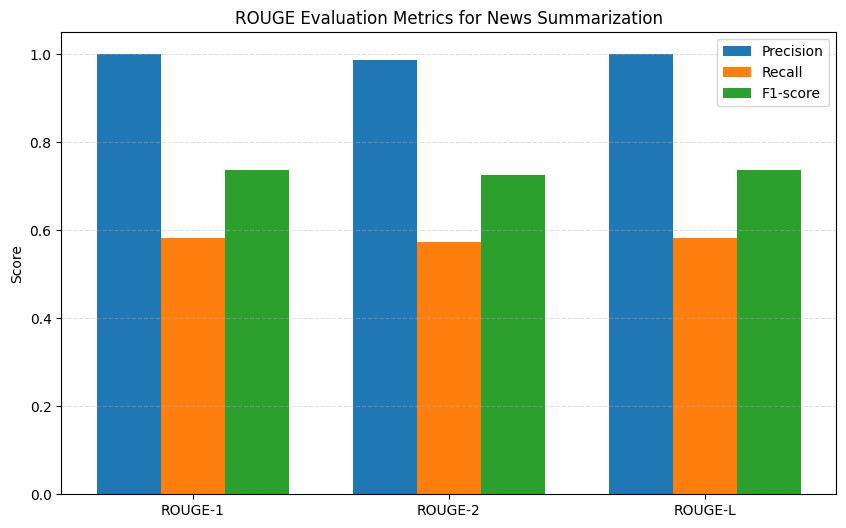

In [ ]:
import matplotlib.pyplot as plt

# Assuming your ROUGE output is stored like this:
# rouge_scores["rouge1"].precision, etc.

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]

precision = [
    rouge_scores["rouge1"].precision,
    rouge_scores["rouge2"].precision,
    rouge_scores["rougeL"].precision
]

recall = [
    rouge_scores["rouge1"].recall,
    rouge_scores["rouge2"].recall,
    rouge_scores["rougeL"].recall
]

f1 = [
    rouge_scores["rouge1"].fmeasure,
    rouge_scores["rouge2"].fmeasure,
    rouge_scores["rougeL"].fmeasure
]

x = range(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar([i - width for i in x], precision, width=width, label="Precision")
plt.bar(x, recall, width=width, label="Recall")
plt.bar([i + width for i in x], f1, width=width, label="F1-score")

plt.xticks(x, metrics)
plt.ylim(0, 1.05)

plt.title("ROUGE Evaluation Metrics for News Summarization")
plt.ylabel("Score")
plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### **ROUGE Performance Evaluation**

The generated summary achieved strong performance across all ROUGE metrics. ROUGE-1 scored 0.7368 F1, ROUGE-2 scored 0.7246 F1, and ROUGE-L scored 0.7368 F1, indicating high lexical and structural similarity between the generated summary and the original article. The precision values are extremely high (close to 1.00), showing that nearly all words and phrases used in the summary are relevant to the source article with very little hallucinated content.

The recall values are lower at around 0.58, which is expected in abstractive news summarization because the goal is to compress the article rather than reproduce every detail. This means the model successfully retained the most important information while omitting less essential supporting details. Overall, the results suggest that the summarization pipeline produces concise, factually grounded summaries with strong relevance to the original article while maintaining good coverage of key news content.

### **Final Interpretation:**

*   **High Precision**: Indicates that the summary is very relevant and to-the-point with respect to the reference. This suggests that the post-processing and cleaning steps were effective in reducing hallucination.

*   **Lower Recall**: Suggests that it is expected because the purpose of summarization is to condense the article while keeping only the most important facts. This means the summary did not reproduce every detail, but successfully preserved the core event, people involved, and major outcomes.

*   **High F1-score**  indicate strong overall summarization performance, showing that the model generated summaries that were highly relevant to the source article while still preserving a substantial amount of its key content.

Overall, these results indicate that the proposed news summarization pipeline produces a concise and highly relevant summaries with strong factual alignment to the original article. Also, our summarizer got to maintain a good coverage of the article’s most important information.

# **Conclusion**

This project developed an abstractive news summarisation pipeline using Hugging Face’s BART model to generate concise yet informative summaries from news articles. The pipeline includes preprocessing, sentence-based chunking for longer articles, token-length validation, duplicate removal, and summary cleaning to improve coherence while reducing redundancy and hallucinated outputs.

Performance was evaluated using ROUGE metrics, which showed high precision, indicating that the generated summaries remained highly relevant to the source articles with minimal irrelevant content. Although recall was lower, it was as expected in abstractive summarisation as the summaries successfully preserved the core information of the original text.

Overall, the final system produced stronger summaries after several refinements, especially in preserving the key news elements such as who, what, when, where, and the resulting consequences. While there is still room for improvement in abstraction and coverage, the summariser demonstrates effective performance in generating a readable and context-aware news summaries while making sure to reduced redundancy and improved factual consistency.